In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8,5)
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/ObesityDataSet.csv")

print("Shape:", df.shape)
df.head()

Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

El dataset presenta buena calidad estructural, sin valores nulos y con una combinación de variables numéricas y categóricas.

In [23]:
def describir_columnas(df):
    descripciones = {
        "Age": "Edad de la persona",
        "Gender": "Género",
        "Height": "Altura en metros",
        "Weight": "Peso en kilogramos",
        "family_history_with_overweight": "Si hay historial familiar de sobrepeso",
        "FAVC": "Consumo frecuente de alimentos altos en calorías",
        "FCVC": "Frecuencia de consumo de vegetales",
        "NCP": "Número de comidas principales al día",
        "CAEC": "Consumo de comida entre comidas (snacks)",
        "SMOKE": "Si la persona fuma",
        "CH2O": "Cantidad de agua consumida diariamente",
        "SCC": "Monitoreo de calorías consumidas",
        "FAF": "Frecuencia de actividad física",
        "TUE": "Tiempo usando dispositivos tecnológicos",
        "CALC": "Consumo de alcohol",
        "MTRANS": "Medio de transporte utilizado",
        "NObeyesdad": "Nivel de obesidad (target)"
    }

    for col in df.columns:
        descripcion = descripciones.get(col, "Sin descripción disponible")
        print(f"{col} → {descripcion}")


describir_columnas(df)

Gender → Género
Age → Edad de la persona
Height → Altura en metros
Weight → Peso en kilogramos
family_history_with_overweight → Si hay historial familiar de sobrepeso
FAVC → Consumo frecuente de alimentos altos en calorías
FCVC → Frecuencia de consumo de vegetales
NCP → Número de comidas principales al día
CAEC → Consumo de comida entre comidas (snacks)
SMOKE → Si la persona fuma
CH2O → Cantidad de agua consumida diariamente
SCC → Monitoreo de calorías consumidas
FAF → Frecuencia de actividad física
TUE → Tiempo usando dispositivos tecnológicos
CALC → Consumo de alcohol
MTRANS → Medio de transporte utilizado
NObeyesdad → Nivel de obesidad (target)


In [4]:
target = "NObeyesdad"
df[target].value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

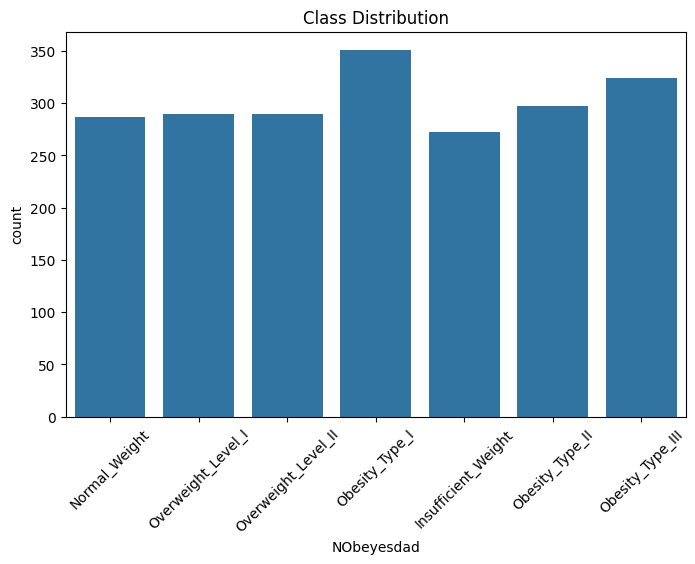

In [6]:
sns.countplot(data=df, x=target)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

La variable objetivo presenta una distribución relativamente balanceada, lo que es adecuado para modelos de clasificación multiclase.

# ANÁLISIS UNIVARIABLE

### Variables numéricas

In [7]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


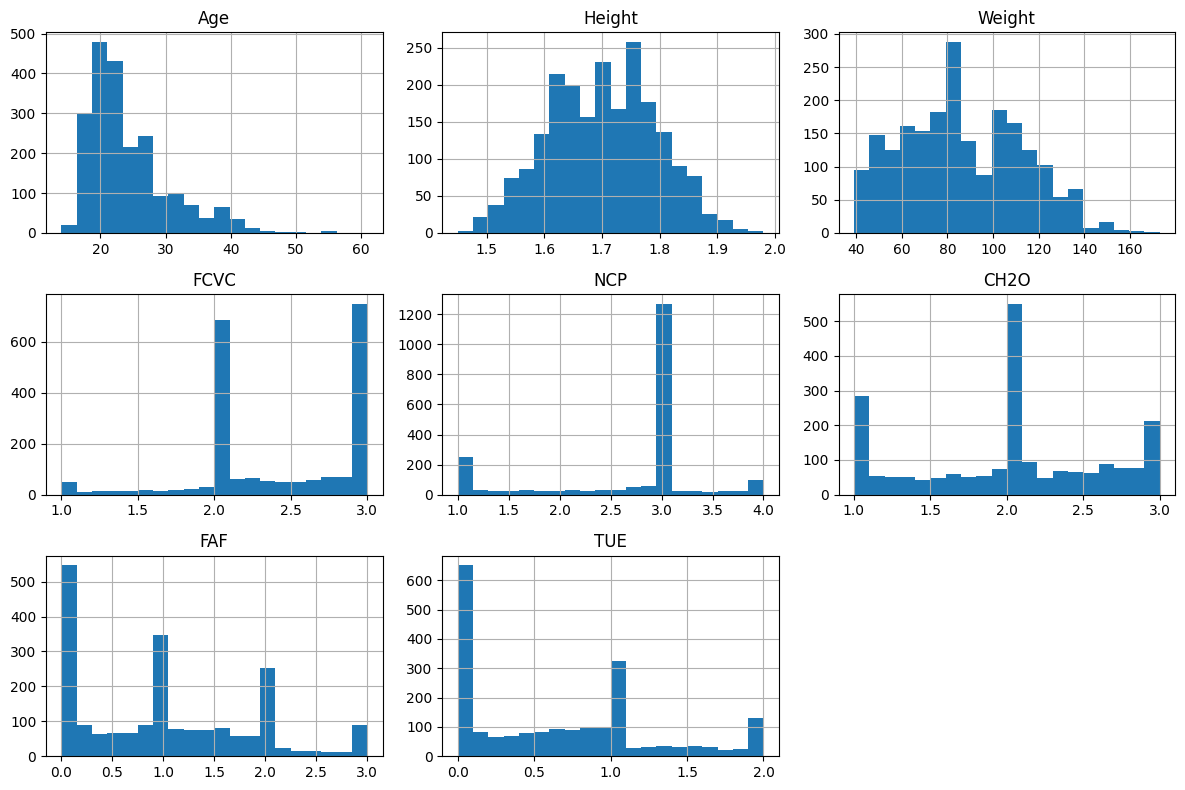

In [8]:
df[num_cols].hist(bins=20, figsize=(12,8))
plt.tight_layout()
plt.show()

### Variables categóricas

Gender
Male      50.592136
Female    49.407864
Name: proportion, dtype: float64


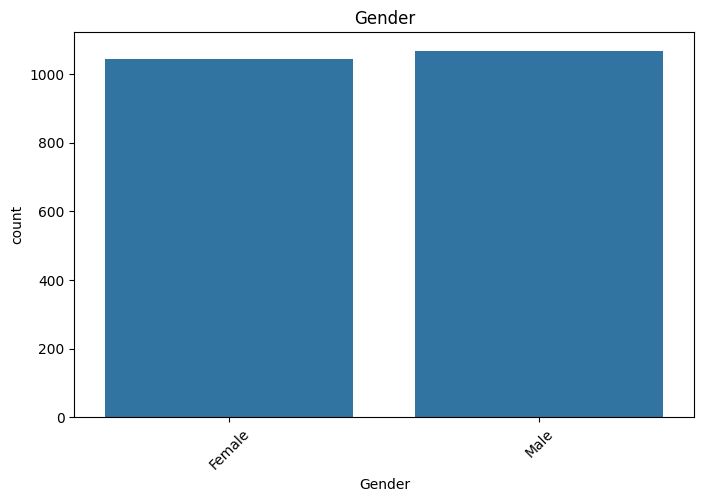

family_history_with_overweight
yes    81.762198
no     18.237802
Name: proportion, dtype: float64


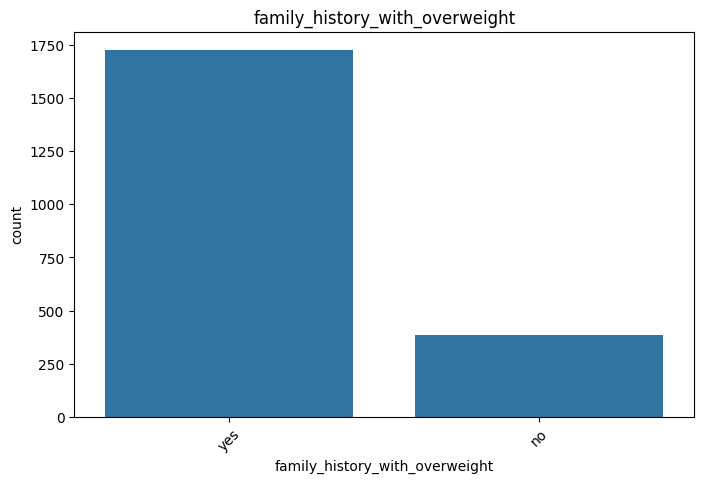

FAVC
yes    88.394126
no     11.605874
Name: proportion, dtype: float64


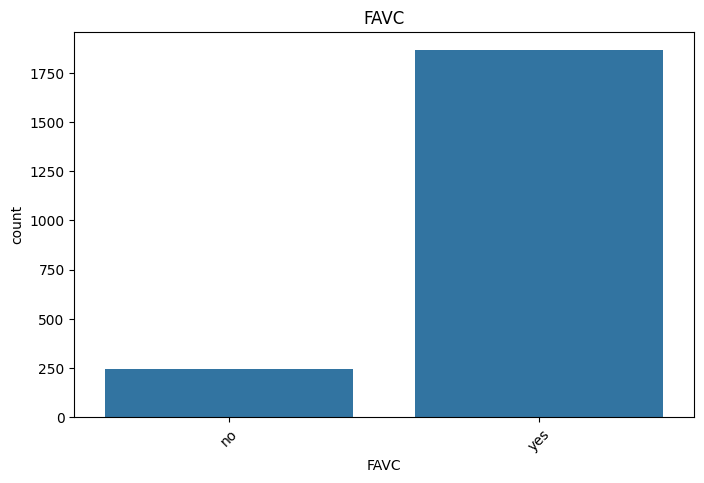

CAEC
Sometimes     83.609664
Frequently    11.463761
Always         2.510658
no             2.415917
Name: proportion, dtype: float64


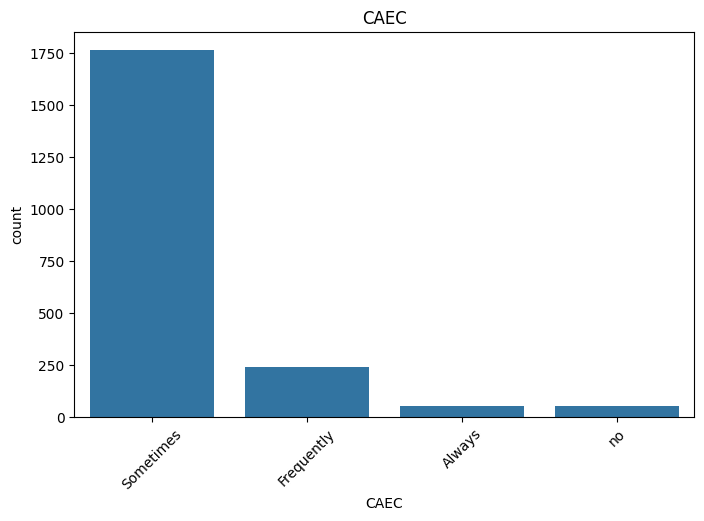

SMOKE
no     97.91568
yes     2.08432
Name: proportion, dtype: float64


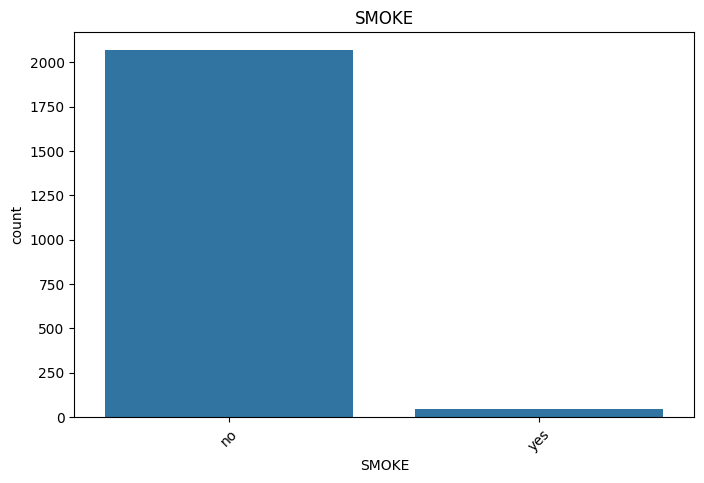

SCC
no     95.452392
yes     4.547608
Name: proportion, dtype: float64


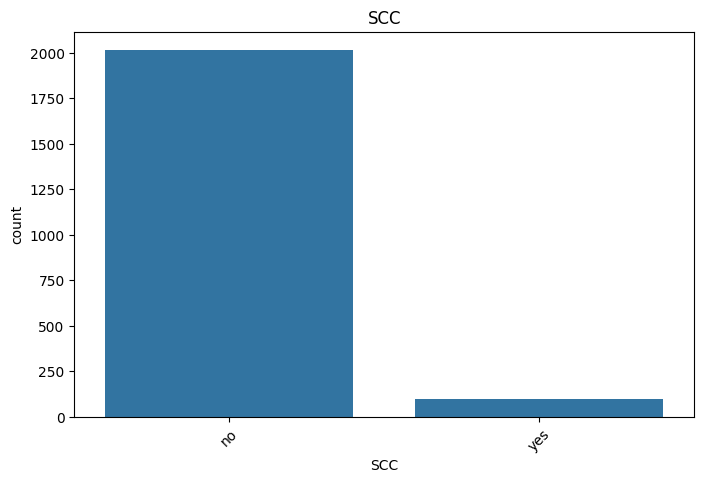

CALC
Sometimes     66.366651
no            30.270014
Frequently     3.315964
Always         0.047371
Name: proportion, dtype: float64


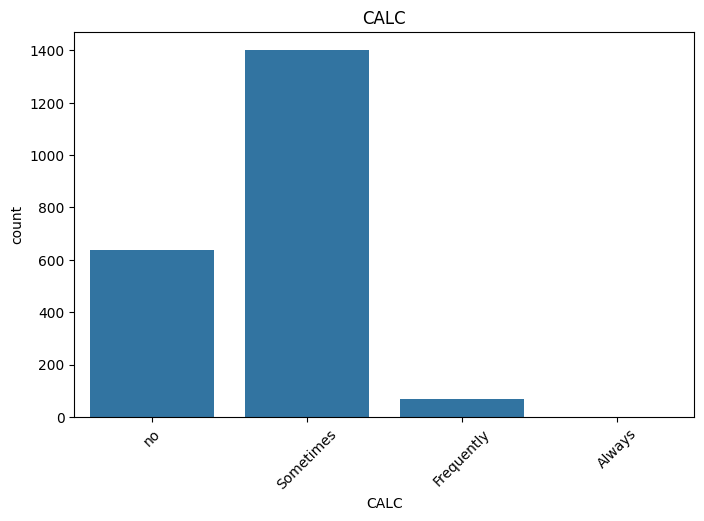

MTRANS
Public_Transportation    74.846045
Automobile               21.648508
Walking                   2.652771
Motorbike                 0.521080
Bike                      0.331596
Name: proportion, dtype: float64


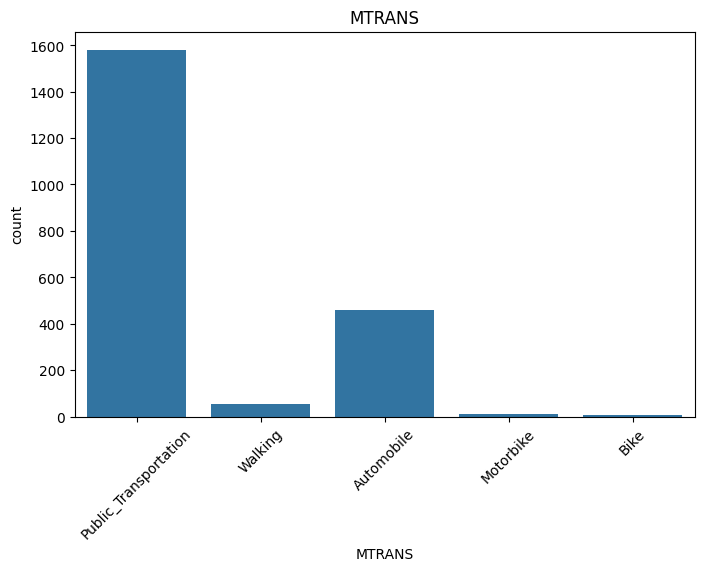

NObeyesdad
Obesity_Type_I         16.627191
Obesity_Type_III       15.348176
Obesity_Type_II        14.069162
Overweight_Level_I     13.737565
Overweight_Level_II    13.737565
Normal_Weight          13.595452
Insufficient_Weight    12.884889
Name: proportion, dtype: float64


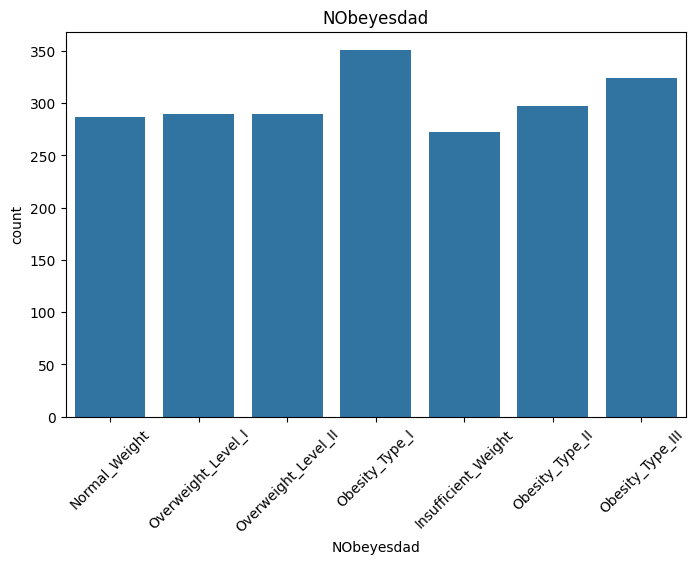

In [30]:
for col in cat_cols:
    print(df[col].value_counts(normalize=True) * 100)
    
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

- Las variables numéricas presentan distribuciones razonables sin valores extremos críticos.
- Las variables categóricas están bien distribuidas.
- No se detectan problemas de calidad en los datos.

# ANÁLISIS BIVARIADO

### Numéricas vs Target

#### Peso vs Obesidad

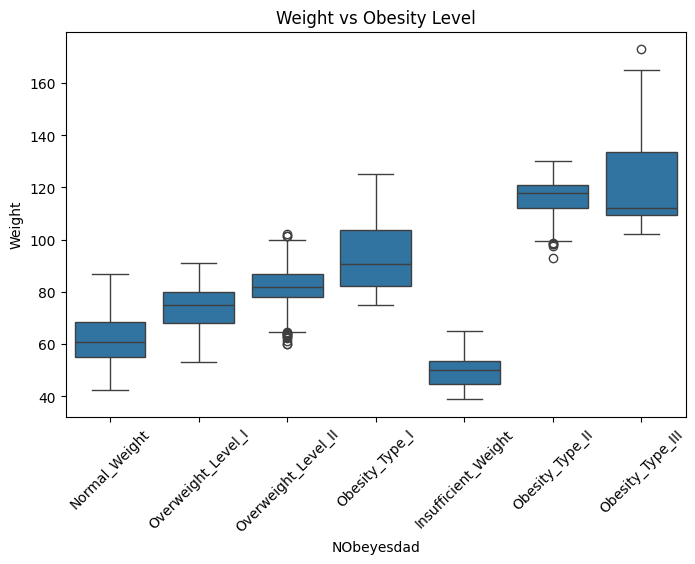

In [9]:
sns.boxplot(data=df, x=target, y="Weight")
plt.xticks(rotation=45)
plt.title("Weight vs Obesity Level")
plt.show()

#### Altura vs Obesidad

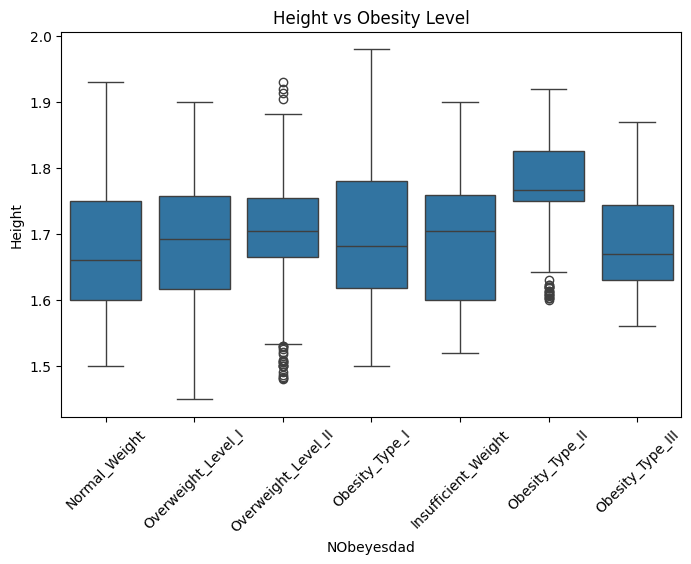

In [10]:
sns.boxplot(data=df, x=target, y="Height")
plt.xticks(rotation=45)
plt.title("Height vs Obesity Level")
plt.show()

### Categóricas vs Target

In [34]:
cat_cols = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
cat_cols

['Gender',
 'family_history_with_overweight',
 'FAVC',
 'CAEC',
 'SMOKE',
 'SCC',
 'CALC',
 'MTRANS',
 'NObeyesdad']

#### Actividad física

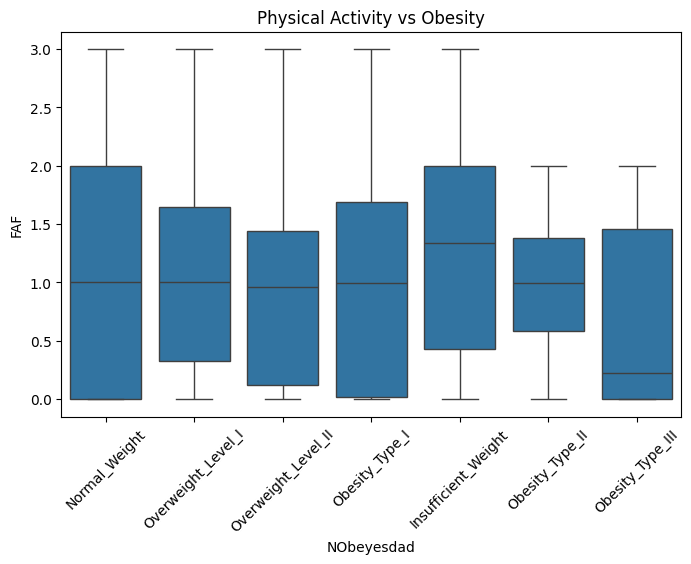

In [35]:
sns.boxplot(data=df, x=target, y="FAF")
plt.xticks(rotation=45)
plt.title("Physical Activity vs Obesity")
plt.show()

#### Consumo de comida alta en calorías

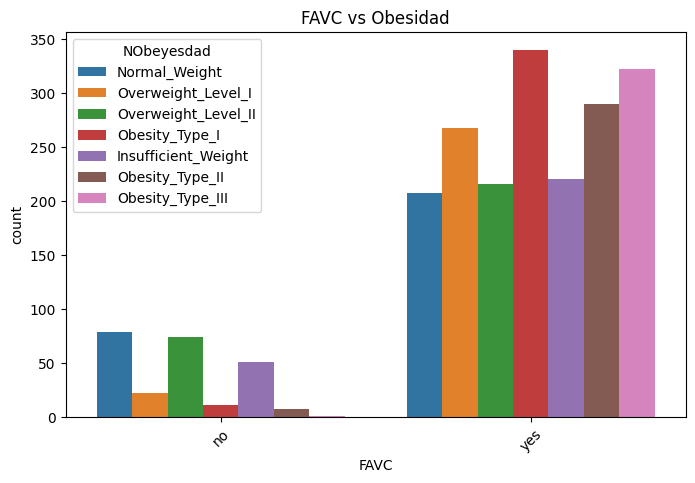

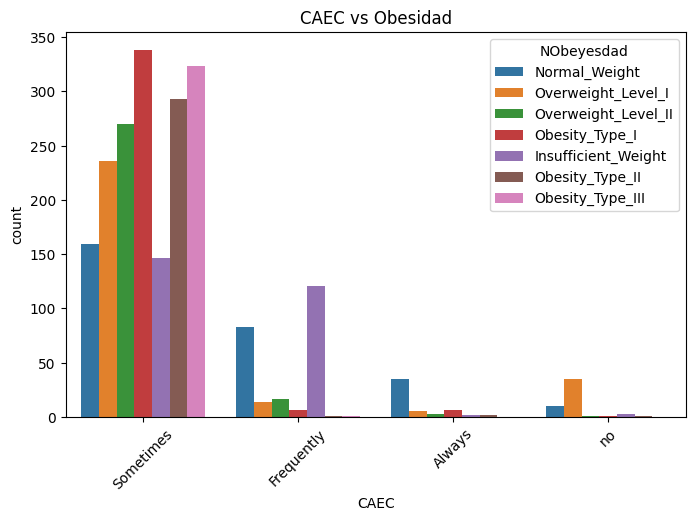

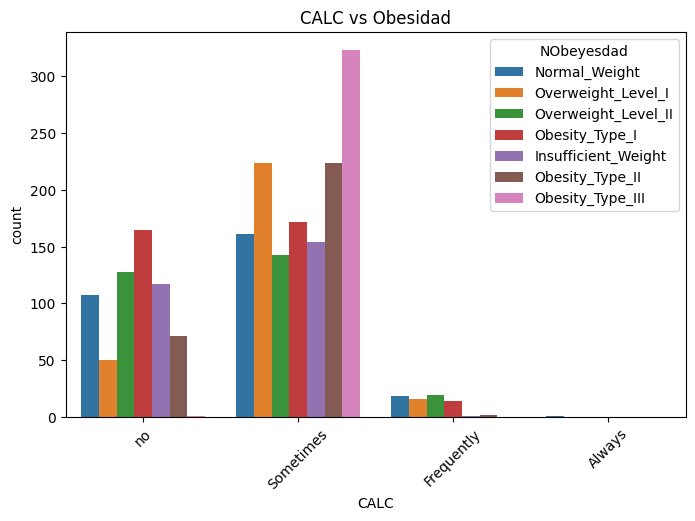

In [37]:
for col in ["FAVC", "CAEC", "CALC"]:
    sns.countplot(data=df, x=col, hue=target)
    plt.title(f"{col} vs Obesidad")
    plt.xticks(rotation=45)
    plt.show()

### Correlación

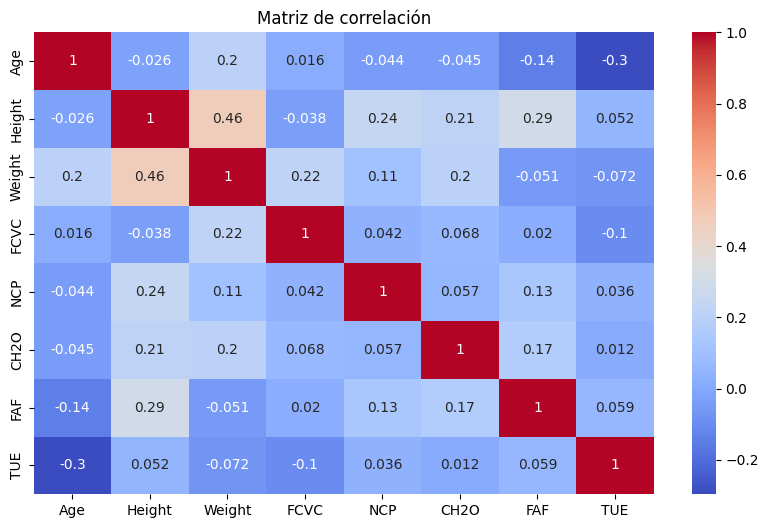

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

- Existe una relación clara entre el peso y el nivel de obesidad.
- La actividad física influye significativamente en la clasificación.
- Variables relacionadas con hábitos alimenticios muestran patrones relevantes.
- Algunas variables numéricas presentan correlaciones útiles para el modelo.

## Outliers

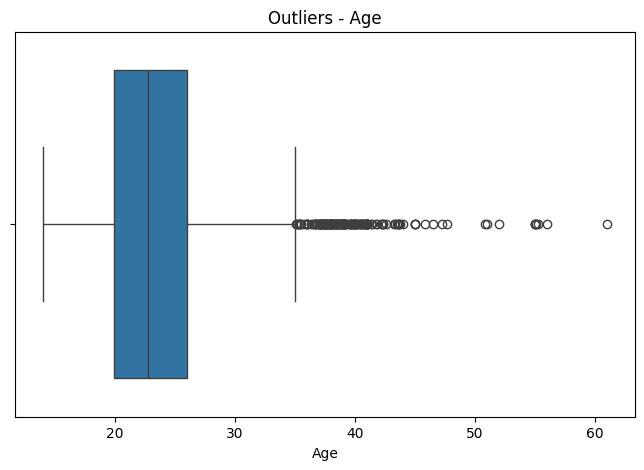

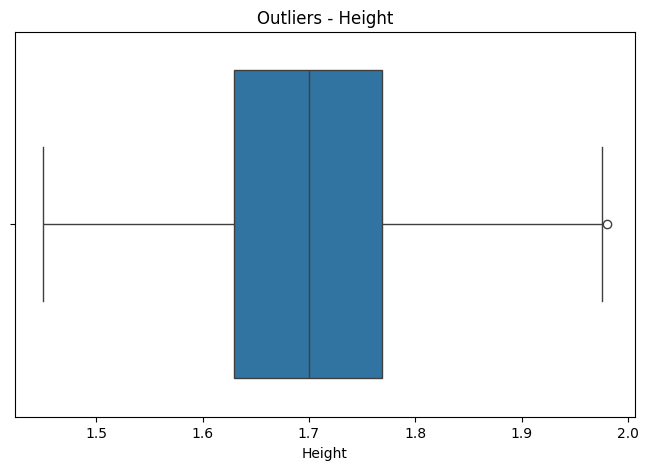

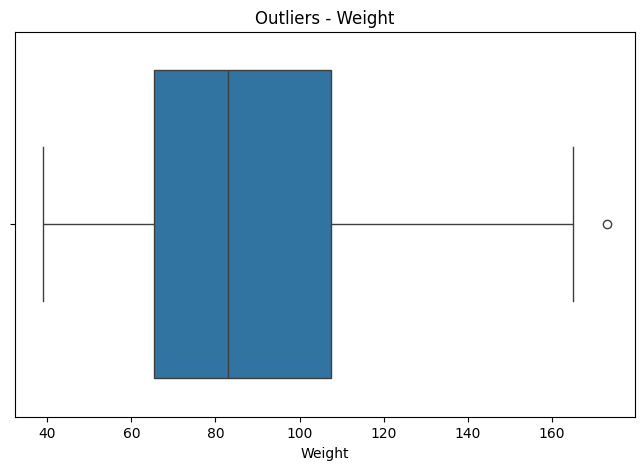

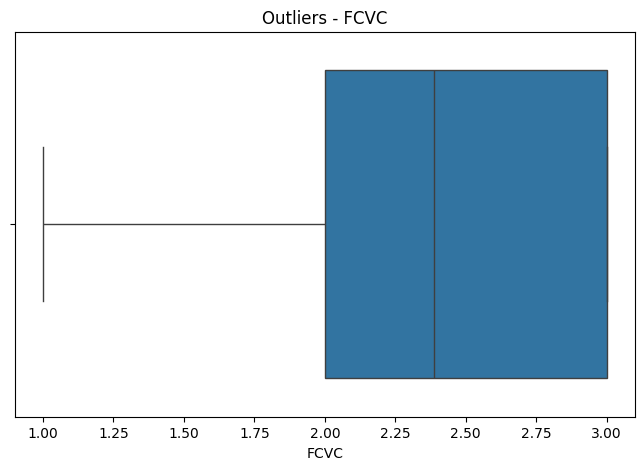

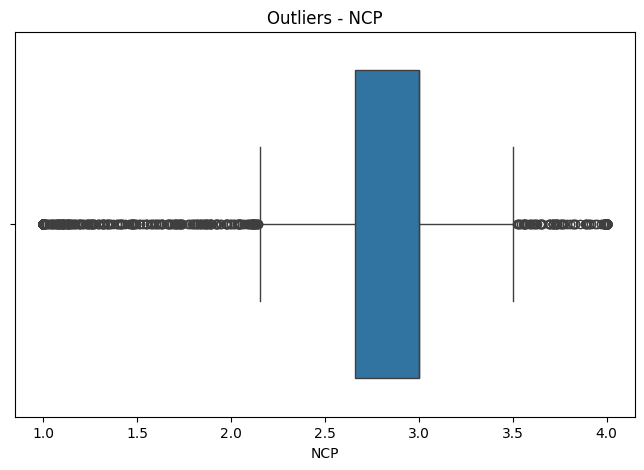

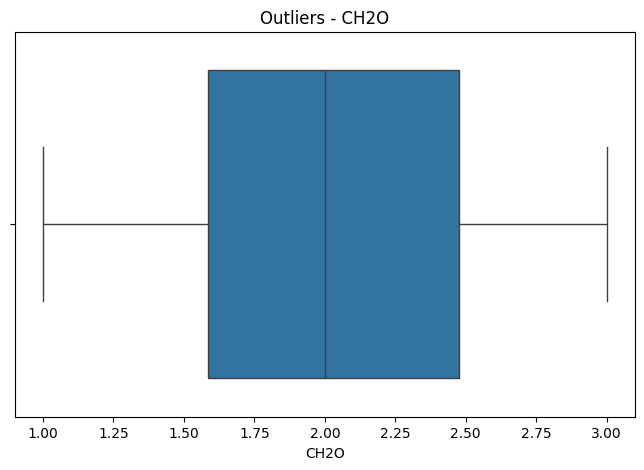

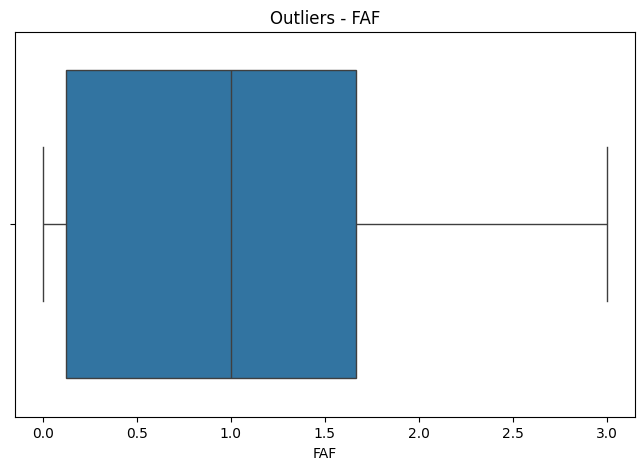

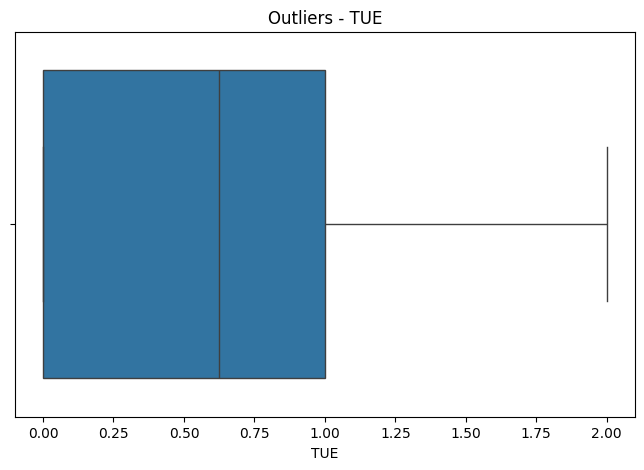

In [14]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Outliers - {col}")
    plt.show()

No se observan outliers extremos que requieran tratamiento inmediato.

### Hipótesis de features importantes

Principales variables esperadas:

1. Weight
2. Height
3. FAF (actividad física)
4. FAVC (alimentación)

## Conclusiones finales

Key Insights:

- El peso es el predictor más relevante del nivel de obesidad.
- Existe relación entre actividad física y niveles de obesidad.
- Las variables categóricas aportan información útil.
- El dataset está limpio y listo para modelado.

Next Steps:

- Encoding de variables categóricas
- Escalado de variables numéricas
- Entrenamiento con RandomForest y XGBoost